### Setup and Load Data

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import mlflow

sns.set_theme(style="whitegrid")

# ── Project root detection ──
PROJECT_ROOT = Path(os.getcwd())
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DB_PATH = PROJECT_ROOT / "data" / "processed" / "recipeiq.duckdb"
FIGURES_DIR = PROJECT_ROOT / "data" / "processed" / "figures"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Load nutrition features
con = duckdb.connect(str(DB_PATH), read_only=True)
recipes = con.execute("""
    SELECT
        RecipeId, Name, RecipeCategory,
        calories_per_serving, protein_per_serving, fat_per_serving,
        sugar_per_serving, fiber_per_serving, sodium_per_serving,
        ingredient_count, complexity_score
    FROM recipes
    WHERE calories_per_serving IS NOT NULL
      AND calories_per_serving BETWEEN 10 AND 2000
      AND protein_per_serving IS NOT NULL
""").fetchdf()
con.close()

print(f"Loaded {len(recipes):,} recipes for clustering")

# Select features for clustering
feature_cols = [
    "calories_per_serving", "protein_per_serving", "fat_per_serving",
    "sugar_per_serving", "fiber_per_serving", "sodium_per_serving",
]

X = recipes[feature_cols].copy()

# Scale features (critical for K-Means — it uses distances)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Feature matrix: {X_scaled.shape}")

Loaded 297,835 recipes for clustering
Feature matrix: (297835, 6)


### Finding Optimal k — Elbow Method + Silhouette

k= 2 | Inertia:    1,289,846 | Silhouette: 0.8222
k= 3 | Inertia:    1,085,941 | Silhouette: 0.8147
k= 4 | Inertia:      900,117 | Silhouette: 0.6462
k= 5 | Inertia:      774,810 | Silhouette: 0.6182
k= 6 | Inertia:      696,006 | Silhouette: 0.4772
k= 7 | Inertia:      630,141 | Silhouette: 0.4613
k= 8 | Inertia:      579,924 | Silhouette: 0.4529
k= 9 | Inertia:      546,468 | Silhouette: 0.3889
k=10 | Inertia:      513,196 | Silhouette: 0.3940


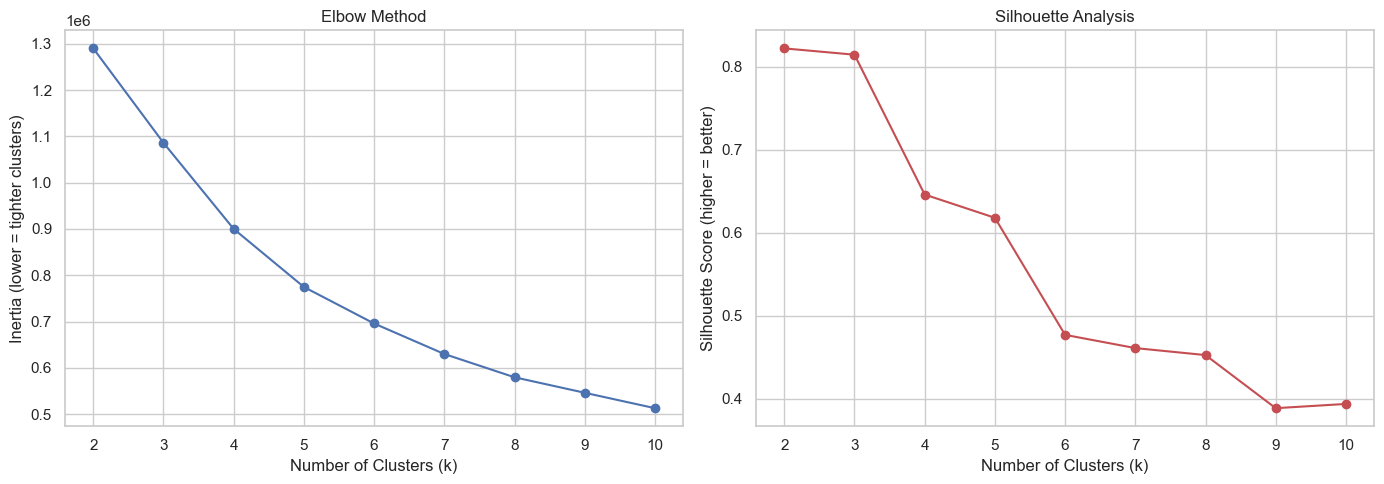

In [3]:
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels, sample_size=10000))
    print(f"k={k:2d} | Inertia: {kmeans.inertia_:>12,.0f} | Silhouette: {silhouette_scores[-1]:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, "bo-")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia (lower = tighter clusters)")
axes[0].set_title("Elbow Method")

axes[1].plot(k_range, silhouette_scores, "ro-")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score (higher = better)")
axes[1].set_title("Silhouette Analysis")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "12_cluster_selection.png", bbox_inches="tight")
plt.show()

### Fitting Final Model

In [4]:
OPTIMAL_K = 5  # Adjust based on your plots

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
recipes["cluster"] = kmeans.fit_predict(X_scaled)

# Log to MLflow
mlflow.set_experiment("RecipeIQ-Clustering")
with mlflow.start_run(run_name=f"KMeans-k{OPTIMAL_K}"):
    mlflow.log_param("k", OPTIMAL_K)
    mlflow.log_metric("inertia", kmeans.inertia_)
    mlflow.log_metric("silhouette", silhouette_score(X_scaled, recipes["cluster"], sample_size=10000))

print(f"Cluster sizes:")
print(recipes["cluster"].value_counts().sort_index())

2026/03/22 18:28:53 INFO mlflow.tracking.fluent: Experiment with name 'RecipeIQ-Clustering' does not exist. Creating a new experiment.


Cluster sizes:
cluster
0     36589
1    257556
2      3111
3       559
4        20
Name: count, dtype: int64


### Naming the Clusters


Cluster Nutrition Profiles (per serving):
         calories_per_serving  protein_per_serving  fat_per_serving  sugar_per_serving  fiber_per_serving  sodium_per_serving
cluster                                                                                                                      
0                       268.6                 13.1             14.0                7.0                2.3               428.3
1                        61.5                  2.7              2.8                2.2                0.6                96.5
2                       953.9                 38.2             57.6               16.7                9.0              1748.3
3                      1101.7                 13.0             23.9              178.9                7.0              1719.9
4                       877.4                 25.0             14.4               48.4               12.3            147887.2


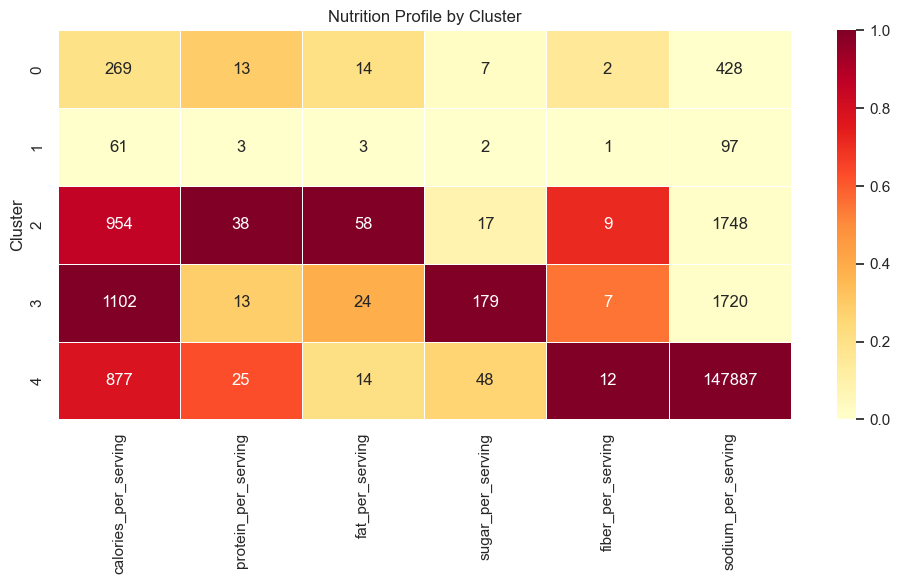

In [5]:
# Compute average nutrition per cluster
cluster_profiles = recipes.groupby("cluster")[feature_cols].mean()
print("\nCluster Nutrition Profiles (per serving):")
print(cluster_profiles.round(1).to_string())

# Normalize for heatmap
from sklearn.preprocessing import MinMaxScaler
cluster_normalized = pd.DataFrame(
    MinMaxScaler().fit_transform(cluster_profiles),
    columns=cluster_profiles.columns,
    index=cluster_profiles.index,
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    cluster_normalized,
    annot=cluster_profiles.round(0).values,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Nutrition Profile by Cluster")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "13_cluster_profiles.png", bbox_inches="tight")
plt.show()

### Visualizing with PCA

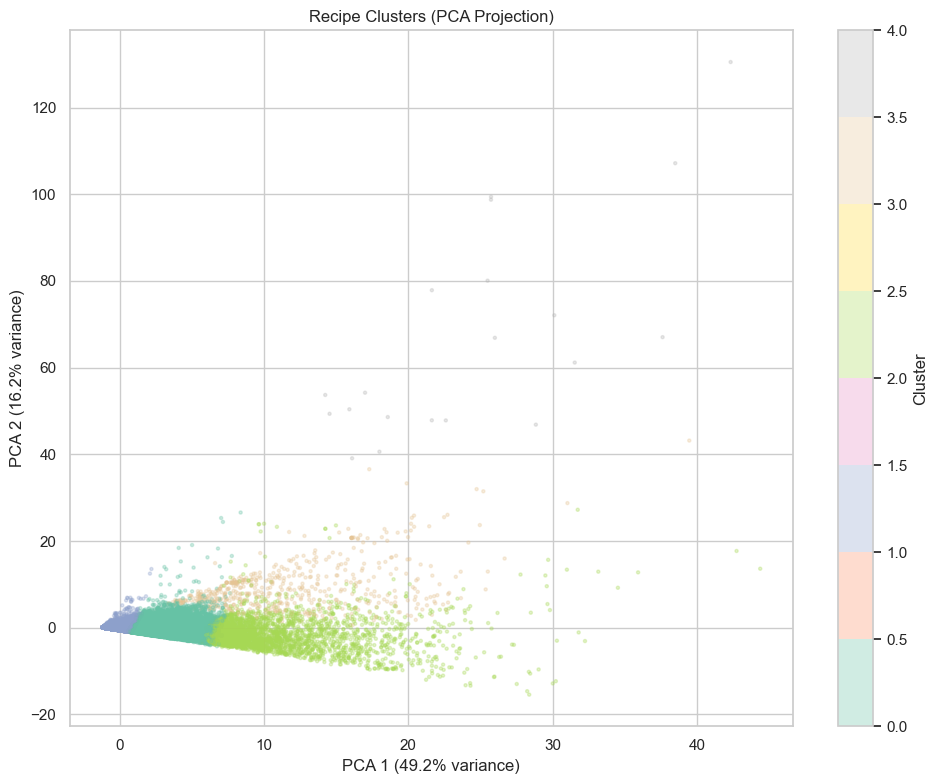

PCA explained variance: 65.3%


In [6]:
# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

recipes["pca_1"] = X_pca[:, 0]
recipes["pca_2"] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    recipes["pca_1"],
    recipes["pca_2"],
    c=recipes["cluster"],
    cmap="Set2",
    alpha=0.3,
    s=5,
)
ax.set_xlabel(f"PCA 1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PCA 2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("Recipe Clusters (PCA Projection)")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "14_cluster_pca.png", bbox_inches="tight")
plt.show()

print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.1%}")

### Saving Clustering Model

In [7]:
import joblib

joblib.dump({
    "kmeans": kmeans,
    "scaler": scaler,
    "feature_cols": feature_cols,
    "pca": pca,
}, MODELS_DIR / "clustering_kmeans.joblib")

print("Saved clustering model")

Saved clustering model
